## Código y librerías para el análisis
Se importan las librerías necesarias para cargar, analizar, visualizar y modelar los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve


## Carga del dataset
Se lee el archivo CSV con la información de clientes para comenzar el análisis.

In [2]:
sampled_data = pd.read_csv('DaviData.csv')

## Exploración inicial de los datos
Se revisa la tabla completa para entender la estructura y las columnas disponibles.

In [3]:
sampled_data

,CLIENTNUM,Segmento,Edad,Genero,Antiguedad_meses,Relaciones_activas,Ingresos,Transacciones_ct,Transacciones_amt,Saldo_rotativo,Limite_credito,Ratio_utilizacion,Estado_cliente,Probabilidad_abandono
0,1001,Alta Renta,45,F,120,5,Alta,85,250000,15000,80000,0.45,Activo,0.12
1,1002,Digital,32,M,48,3,Media,40,75000,5000,30000,0.25,Cancelado,0.78
2,1003,Nómina,29,F,36,2,Baja,25,30000,2000,15000,0.18,Activo,0.22
3,1004,Alta Renta,52,M,180,6,Alta,120,400000,20000,100000,0.60,Activo,0.09
4,1005,Digital,41,F,60,4,Media,55,120000,8000,50000,0.35,Activo,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Nómina,30,M,45,2,Baja,29,41000,2550,16500,0.15,Activo,0.20
96,1097,Alta Renta,50,F,162,5,Alta,114,365000,20200,96000,0.54,Activo,0.09
97,1098,Digital,37,M,81,4,Media,71,152000,10900,64500,0.41,Activo,0.29
98,1099,Nómina,38,F,89,4,Baja,49,87000,6050,35500,0.28,Activo,0.23


## Variables del dataset
Se documentan las variables principales incluidas en el archivo de datos.

El conjunto de datos "DaviData.csv" contiene las siguientes variables:

- CLIENTNUM
- Segmento
- Edad
- Genero
- Antiguedad_meses
- Relaciones_activas
- Ingresos
- Transacciones_ct
- Transacciones_amt
- Saldo_rotativo
- Limite_credito
- Ratio_utilizacion
- Estado_cliente
- Probabilidad_abandono

## Separación entre clientes activos y cancelados
Se dividen los clientes en dos grupos para comparar su comportamiento.

In [4]:
clientes_activos = sampled_data[sampled_data['Estado_cliente'] == 'Activo']
clientes_cancelados = sampled_data[sampled_data['Estado_cliente'] == 'Cancelado']

print('Clientes activos:', len(clientes_activos))
print('Clientes cancelados:', len(clientes_cancelados))

Clientes activos: 88
Clientes cancelados: 12


## Entrenamiento, accuracy y ROC
Se prepara la variable objetivo, se entrena un Random Forest y se evalúa su desempeño.

Accuracy: 0.8667
ROC AUC: 0.8542

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.67      0.67      0.67         6

    accuracy                           0.87        30
   macro avg       0.79      0.79      0.79        30
weighted avg       0.87      0.87      0.87        30



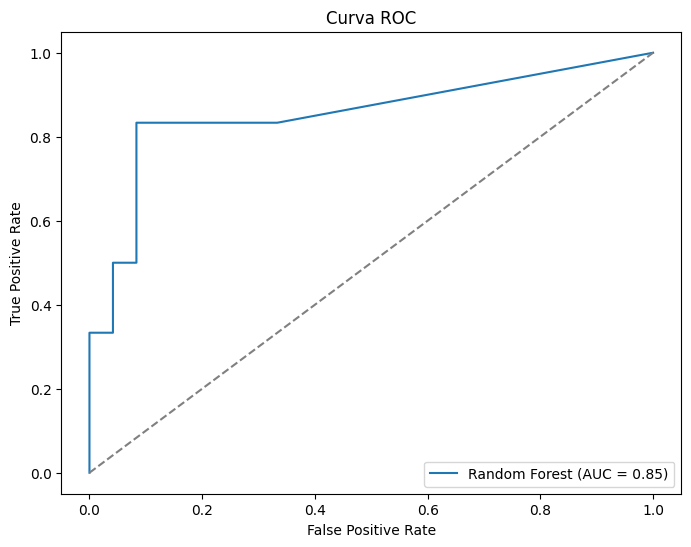

In [ ]:
df_model = sampled_data.copy()

y = df_model['Estado_cliente'].map({'Activo': 0, 'Cancelado': 1})#var objetivo
X = df_model.drop(columns=['Estado_cliente', 'Probabilidad_abandono'])#var para predecir :)
X_encoded = pd.get_dummies(X, drop_first=True) # One-hot encoding

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42
) #vamos a dividir lo de train y test


#vamos a hacer un modelo de random forest para predecir el abandono de clientes
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
#aca ya lo entrenamos :)
random_forest_model.fit(X_train, y_train)

# Evaluar el modelo con métricas de clasificacion
predictions = random_forest_model.predict(X_test)  #con 0 y 1, vamos a predecir el abandono de clientes
probabilities = random_forest_model.predict_proba(X_test)[:, 1] #probabilidades de abandono (1) para calcular el AUC
accuracy = accuracy_score(y_test, predictions)#accuracy es la proporción de predicciones correctas sobre el total de casos evaluados
auc = roc_auc_score(y_test, probabilities)#AUC mide la capacidad del modelo para distinguir entre clases, con 1 siendo perfecto y 0.5 equivalente a una predicción aleatoria



print('Accuracy:', round(accuracy, 4))
print('ROC AUC:', round(auc, 4))
print('\nReporte de clasificación:\n')
print(classification_report(y_test, predictions))

fpr, tpr, _ = roc_curve(y_test, probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

## Importancia de variables
Se identifican las variables más influyentes según el modelo entrenado.

/var/folders/xn/hk31cmbn33j2sp_0424kxs940000gn/T/ipykernel_93466/3466494871.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')


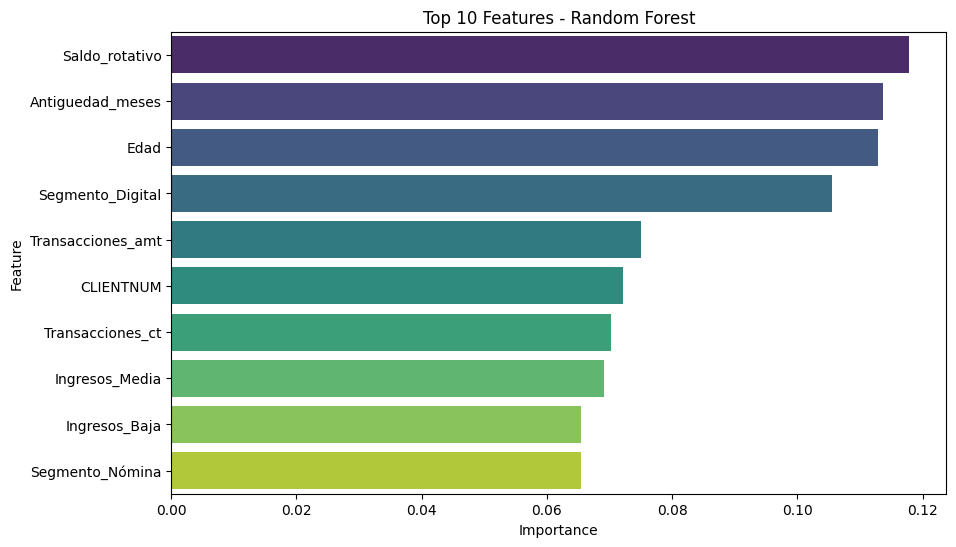

,Feature,Importance
0,Saldo_rotativo,0.117894
1,Antiguedad_meses,0.113734
2,Edad,0.112833
3,Segmento_Digital,0.105493
4,Transacciones_amt,0.075098
5,CLIENTNUM,0.072085
6,Transacciones_ct,0.070218
7,Ingresos_Media,0.069058
8,Ingresos_Baja,0.065490
9,Segmento_Nómina,0.065436


In [ ]:

#vamos a saber cual es la impirtancia de cada variable para predecir el abandono de clientes
feature_importances = random_forest_model.feature_importances_

#aca lo que hacemos es crear una tabla con dos lanes una que nombre otra que sea el calculo yaimplementado
features_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': feature_importances
})



#ordenamos por importancia
features_df = features_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)


#visualizamos las 10 variables mas importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


#mostramos las 10 variables mas importantes
features_df.head(10)

## Predicciones y matriz de confusión
Se comparan las predicciones con los valores reales y se visualiza la matriz de confusión.

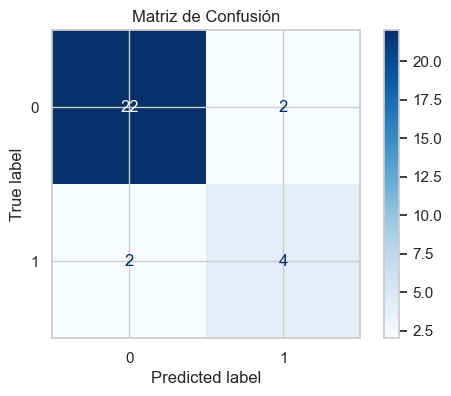

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


#creamos una tabla con las predicciones, probabilidades y valores reales
pred_df = pd.DataFrame({
    'y_true': y_test.values, #aca trabajamos con lo que son los valores reales lo de 1 y 0
    'prediction': predictions, #tenemos la prediccion del 0 y el 1
    'probability': probabilities # y pues la probbilidad de esos dos
}, index=y_test.index)


# Mostrar primeras filas de la tabla
pred_df_display = pred_df.sort_values(by='probability', ascending=False)#esto lo que hace es orgaizar de > a <
pred_df_display.head(20) #ponemos el head que muestra 



# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])


#ESTO ES PARAVER LOS ERRORES DE CLASIFICACION
# TN FP FN TP
fig, ax = plt.subplots(figsize=(6,4))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

## REFLEXIÓN DEL GRUPO

1	¿Qué variable fue la más importante? ¿Tiene sentido con su problema? ¿Por qué?  (4 pts)

La variable más importante fue Saldo_rotativo. 
Tiene sentido porque representa la deuda que el cliente no paga a tiempo, se ve que las personas con alto saldo rotativo tienen problemas financieros o quedan insatisfechos, lo que lo hace más propenso a cancelar su tarjeta.

2	¿Qué accuracy obtuvo el modelo? ¿Es suficientemente bueno para el problema que eligieron?  (4 pts)

El modelo Random Forest alcanzó 87% de accuracy. Aunque, al revisar el recall de la clase "Cancelado" es de solo 67%, se ve que 1 de cada 3 clientes que se van no fueron detectados. Para la compañia esto es inaceptable porque el costo de perder un cliente es mayor que el de una promoción innecesaria. Entonces el accuracy no es suficiente para este problema.

3	¿Qué limitaciones encontraron? ¿Qué cambiarían si tuvieran más datos o más tiempo?  (4 pts)

El principal problema fue el desequilibrio de clases, lo que hizo que el modelo aprendiera mejor a predecir Activo que Cancelado. Y con más datos, buscaríamos más variables relevantes como quejas al servicio al cliente. Con más tiempo, haríamos una búsqueda de hiperparámetros para optimizar el modelo.

4	¿En qué situación real podría aplicarse este modelo? ¿A quién le serviría?  (3 pts)

Se iría más para los bancos ya que estos son los que usan las tarjetas y la finalidad del programa es principalmente mirar si cancelan tarjetas o no viendo con que clientes si se puede seguir para quizás darles descuentos o promociones a los que se queden.